In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/shannon/COMM 557/COMM 557 - Final Project/data/UPDATED_dataset_with_artist_pop.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())

print("Original target distribution:")
print(df['chart_longevity'].value_counts(dropna=False))
print(f"\nTotal rows: {len(df)}")


Dataset loaded: 4521 rows, 33 columns

First few rows:
      track_name    artist_name  danceability  energy  loudness  mode  key  \
0           Wow.    Post Malone         833.0   539.0    -7.399     0   11   
1           Wow.    Post Malone         833.0   539.0    -7.399     0   11   
2  thank u, next  Ariana Grande         724.0   647.0    -5.642     1    1   
3  thank u, next  Ariana Grande         724.0   647.0    -5.642     1    1   
4     Without Me         Halsey         752.0   488.0    -7.050     1    6   

   speechiness  acousticness  instrumentalness  ...  community_simplified  \
0     178.0000        163.00          0.000002  ...                     0   
1     178.0000        163.00          0.000002  ...                     0   
2       0.0658          0.28          0.000000  ...                 Other   
3       0.0658          0.28          0.000000  ...                 Other   
4       0.0705        297.00          0.000009  ...                     5   

   label_shor

In [5]:
#Filter to Binary Classification 

df_clean = df[df['chart_longevity'].isin(['brief', 'sustained'])].copy()

print(f"--- After filtering for binary classification ---")
print(f"Rows removed (unknown/blank): {len(df) - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")
print(f"\nFinal target distribution:")
print(df_clean['chart_longevity'].value_counts())
print(f"\nClass proportions:")
print(df_clean['chart_longevity'].value_counts(normalize=True))


numerical_features = [
    'danceability', 
    'energy', 
    'loudness', 
    'speechiness',
    'acousticness', 
    'instrumentalness', 
    'liveness', 
    'tempo', 
    'duration_ms',
    'max_artist_popularity'  # Artist popularity from Spotify API
]

categorical_features = [
    'source',                    # TikTok vs Spotify (KEY for RQ)
    'lyrics_missing',            # TRUE/FALSE for whether lyrics are missing
    'topic_label',               # Lyrical themes (KEY for RQ)
    'community_simplified',      # Community clusters (KEY for RQ)
    'category_simplified',       # Genre category
    'label_short_simplified'     # Record label
]

numerical_features = [f for f in numerical_features if f in df_clean.columns]
categorical_features = [f for f in categorical_features if f in df_clean.columns]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")


--- After filtering for binary classification ---
Rows removed (unknown/blank): 772
Rows remaining: 3749

Final target distribution:
chart_longevity
sustained    2006
brief        1743
Name: count, dtype: int64

Class proportions:
chart_longevity
sustained    0.535076
brief        0.464924
Name: proportion, dtype: float64
Numerical features (10): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'tempo', 'duration_ms', 'max_artist_popularity']

Categorical features (6): ['source', 'lyrics_missing', 'topic_label', 'community_simplified', 'category_simplified', 'label_short_simplified']


In [7]:
# Select features and target
all_features = numerical_features + categorical_features
X = df_clean[all_features].copy()
y = df_clean['chart_longevity']

# Check for missing values
print("Missing values in features:")
missing_summary = X.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("No missing values in features!")

# Handle missing values
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())
X[categorical_features] = X[categorical_features].fillna('Missing')

# Check for rare categories that might cause issues
print("\n--- Checking categorical feature distributions ---")
for cat_col in categorical_features:
    n_unique = X[cat_col].nunique()
    value_counts = X[cat_col].value_counts()
    rare_categories = value_counts[value_counts < 5].shape[0]
    print(f"{cat_col}: {n_unique} unique values, {rare_categories} rare categories (<5 occurrences)")
    
    # Show smallest categories
    if rare_categories > 0:
        print(f"  Smallest categories: {value_counts.tail(3).to_dict()}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")


Missing values in features:
No missing values in features!

--- Checking categorical feature distributions ---
source: 1 unique values, 0 rare categories (<5 occurrences)
lyrics_missing: 1 unique values, 0 rare categories (<5 occurrences)
topic_label: 19 unique values, 1 rare categories (<5 occurrences)
  Smallest categories: {'Summer Memories': 13, 'Space / Isolation Metaphors': 12, 'Social Identity & Belonging': 4}
community_simplified: 16 unique values, 0 rare categories (<5 occurrences)
category_simplified: 7 unique values, 0 rare categories (<5 occurrences)
label_short_simplified: 16 unique values, 0 rare categories (<5 occurrences)

Feature matrix shape: (3749, 16)
Target variable shape: (3749,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Train size: 2999 (80.0%)
Test size: 750 (20.0%)

Train set class distribution:
chart_longevity
sustained    1605
brief        1394
Name: count, dtype: int64

Test set class distribution:
chart_longevity
sustained    401
brief        349
Name: count, dtype: int64


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            drop='first',                    # Drop first category to avoid multicollinearity
            handle_unknown='ignore',         # Ignore unknown categories in test set
            sparse_output=False
        ), categorical_features)
    ]
)

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='lbfgs',  # Changed from 'saga' - more stable
        class_weight=None  # Will be tuned in grid search
    ))
])

print("Pipeline created successfully!")
print(pipeline)

Pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'tempo',
                                                   'duration_ms',
                                                   'max_artist_popularity']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                          

In [13]:
print("="*70)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {
    'accuracy': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1),
    'precision': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='precision_macro', n_jobs=-1),
    'recall': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall_macro', n_jobs=-1),
    'f1': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
}

for metric, scores in cv_scores.items():
    print(f"{metric.capitalize():12s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


5-FOLD STRATIFIED CROSS-VALIDATION
Accuracy    : 0.5575 (+/- 0.0087)
Precision   : 0.5517 (+/- 0.0096)
Recall      : 0.5457 (+/- 0.0082)
F1          : 0.5377 (+/- 0.0079)


In [15]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

param_grid = {
    'classifier__C': [0.1, 1, 10, 100, 1000],  # Increased C values (less regularization)
    'classifier__penalty': ['l2'],  # Start with L2 only
    'classifier__class_weight': [None, 'balanced']  # Test both options
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

# Show top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\nTop 5 parameter combinations:")
print(top_5.to_string(index=False))


HYPERPARAMETER TUNING
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Best CV F1 score: 0.5640

Top 5 parameter combinations:
                                                                                      params  mean_test_score  std_test_score
   {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}         0.563967        0.010934
  {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}         0.563494        0.011336
 {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}         0.562569        0.012237
{'classifier__C': 1000, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}         0.562555        0.010850
 {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}         0.559601        0.011

In [17]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, digits=4))

TEST SET PERFORMANCE

Accuracy: 0.5280

              precision    recall  f1-score   support

       brief     0.4927    0.4842    0.4884       349
   sustained     0.5577    0.5661    0.5619       401

    accuracy                         0.5280       750
   macro avg     0.5252    0.5252    0.5252       750
weighted avg     0.5275    0.5280    0.5277       750



<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

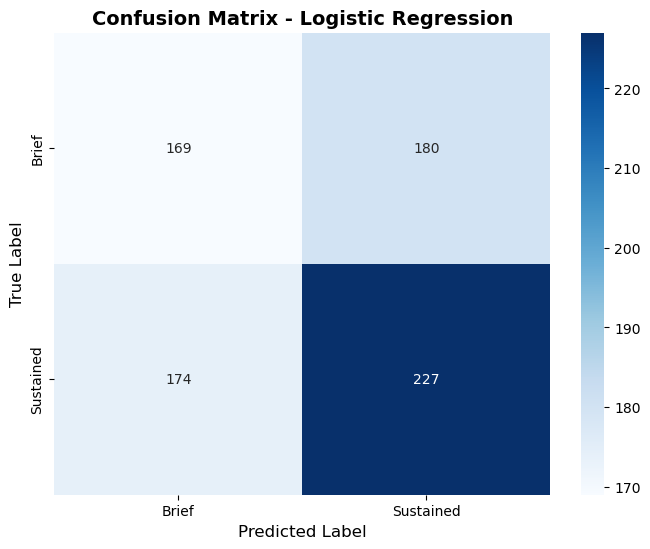

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Brief', 'Sustained'],
            yticklabels=['Brief', 'Sustained'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout

In [21]:
print("="*70)
print("FEATURE IMPORTANCE (COEFFICIENTS)")
print("="*70)

# Get feature names after preprocessing
feature_names = numerical_features.copy()

# Get one-hot encoded feature names
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names.extend(cat_names)

# Get coefficients
coefficients = best_model.named_steps['classifier'].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Odds_Ratio': np.exp(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Display top features
print("\nTop 25 Most Important Features:")
print(coef_df.head(25).to_string(index=False))

# Save to CSV
coef_df.to_csv('/Users/shannon/COMM 557/COMM 557 - Final Project/data/logistic_coefficients.csv', index=False)
print("\n✓ Full coefficient table saved to data folder: 'logistic_coefficients.csv'")

FEATURE IMPORTANCE (COEFFICIENTS)

Top 25 Most Important Features:
                                     Feature  Coefficient  Abs_Coefficient  Odds_Ratio
                       topic_label_Dance-Pop    -1.196213         1.196213    0.302337
     topic_label_Space / Isolation Metaphors     1.182472         1.182472    3.262428
     topic_label_Social Identity & Belonging    -0.893998         0.893998    0.409017
                  topic_label_Pop Love Songs     0.523781         0.523781    1.688400
     topic_label_Perseverance and Positivity    -0.492110         0.492110    0.611335
             topic_label_Holiday / Christmas     0.369349         0.369349    1.446793
  label_short_simplified_Latin Trap / Urbano     0.304422         0.304422    1.355842
                      community_simplified_6     0.304422         0.304422    1.355842
 topic_label_Independence & Self-empowerment     0.275736         0.275736    1.317500
                                 speechiness    -0.274319      

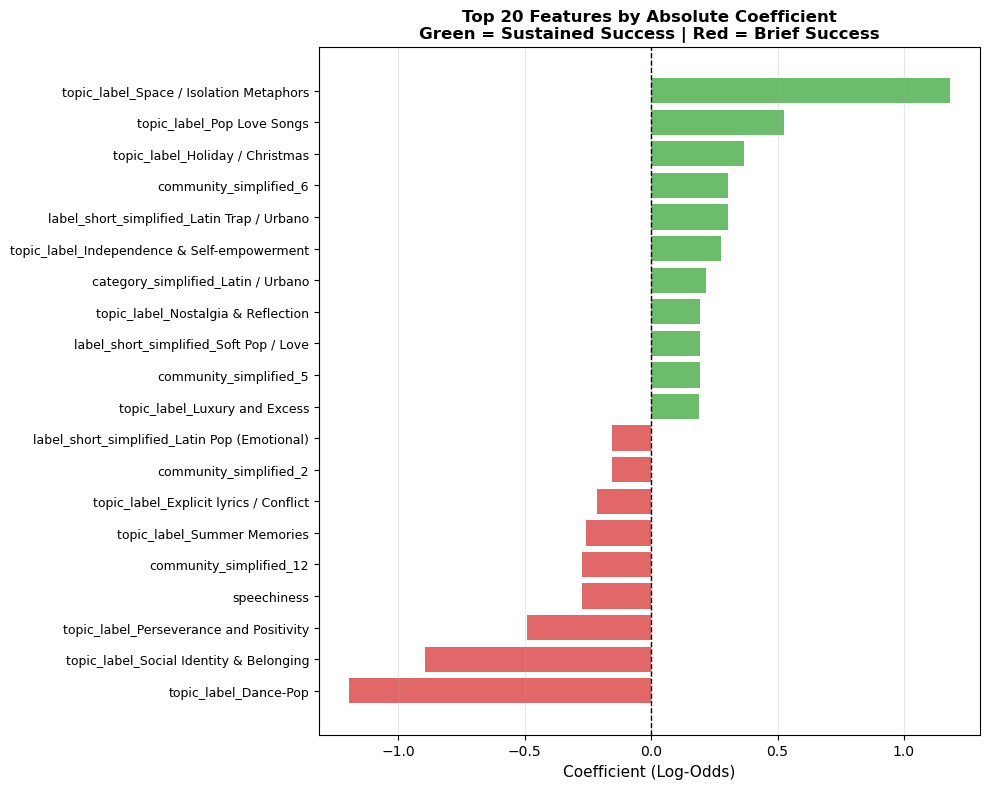

In [23]:
plt.figure(figsize=(10, 8))
top_20 = coef_df.head(20).sort_values('Coefficient')
colors = ['#d62728' if x < 0 else '#2ca02c' for x in top_20['Coefficient']]

plt.barh(range(len(top_20)), top_20['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'], fontsize=9)
plt.xlabel('Coefficient (Log-Odds)', fontsize=11)
plt.title('Top 20 Features by Absolute Coefficient\nGreen = Sustained Success | Red = Brief Success', 
          fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Found 41 lyrical features in the model:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

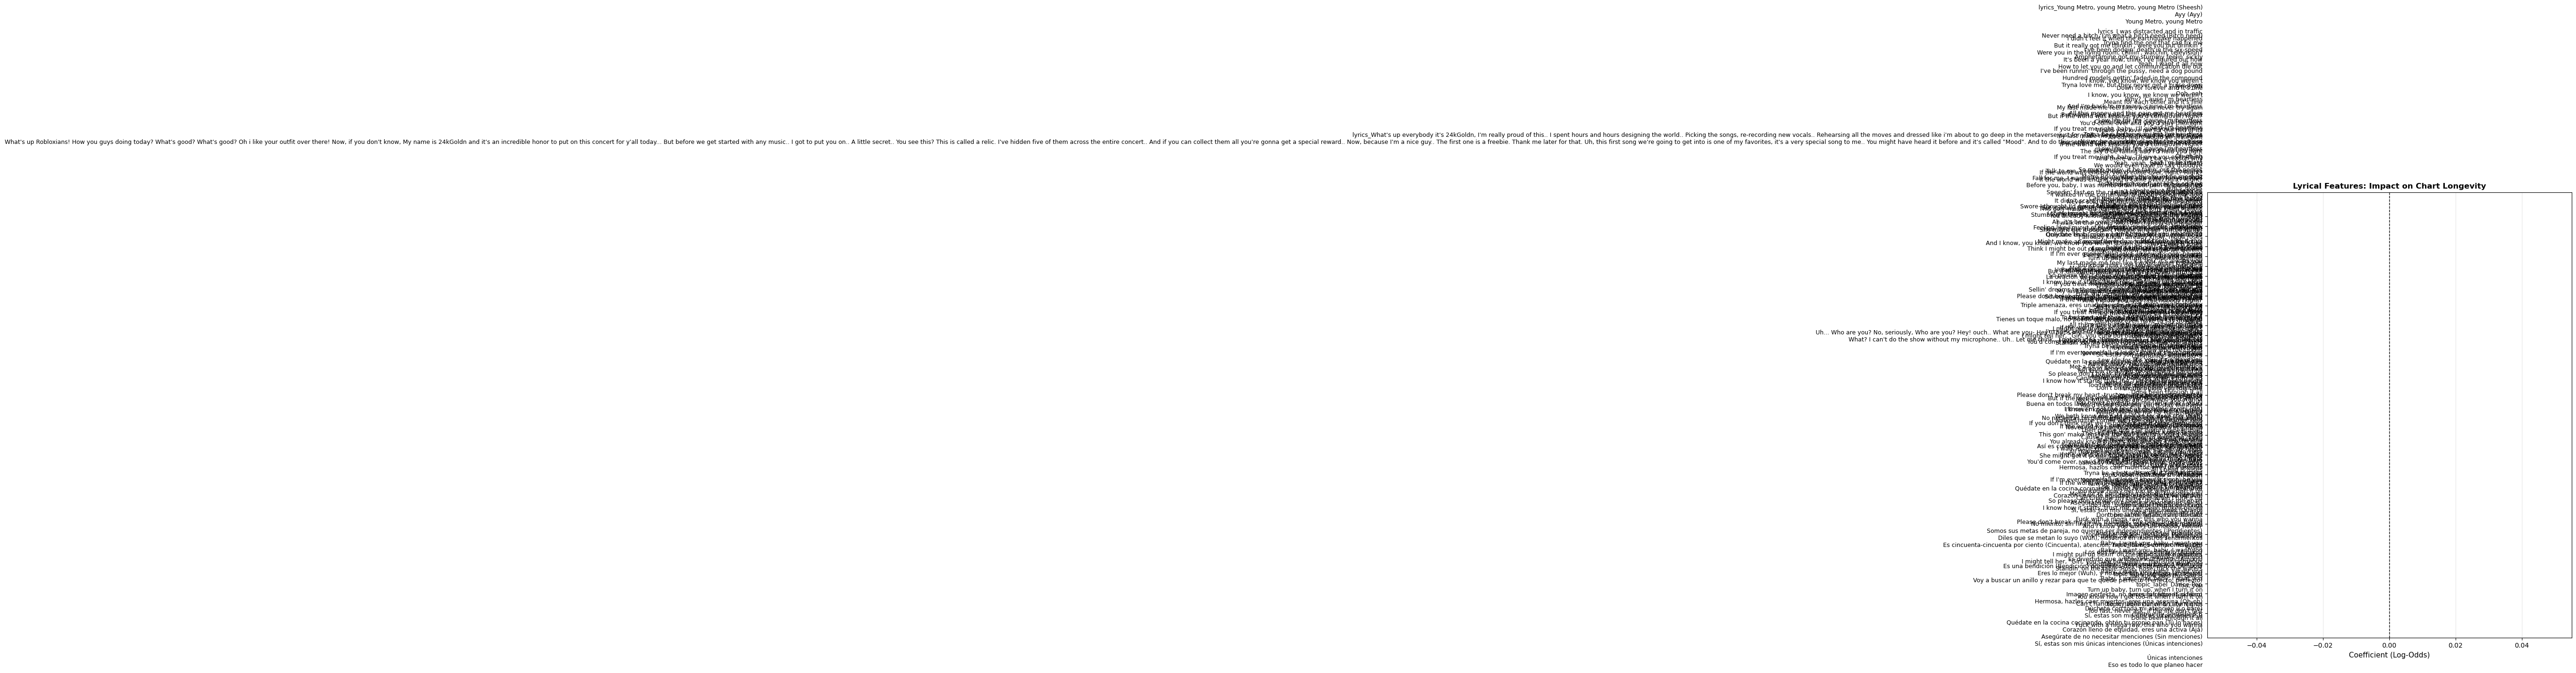

In [42]:
lyrical_keywords = ['lyrics', 'topic', 'community', 'theme']
lyrical_features = coef_df[coef_df['Feature'].str.contains('|'.join(lyrical_keywords), case=False, na=False)]

if len(lyrical_features) > 0:
    print(f"\nFound {len(lyrical_features)} lyrical features in the model:")
    print(lyrical_features.to_string(index=False))
    
    print("\n" + "-"*70)
    print("INTERPRETATION GUIDE:")
    print("-"*70)
    print("• Positive coefficients → Associated with SUSTAINED chart success")
    print("• Negative coefficients → Associated with BRIEF chart success")
    print("• Odds Ratio > 1 → Increases odds of sustained success")
    print("• Odds Ratio < 1 → Decreases odds of sustained success")
    print("\nExample: If Odds Ratio = 2.5, that feature increases the odds")
    print("         of sustained success by 150% (2.5x more likely)")
    
    # Visualize lyrical features
    if len(lyrical_features) >= 3:
        plt.figure(figsize=(10, max(6, len(lyrical_features)*0.3)))
        lyrical_sorted = lyrical_features.sort_values('Coefficient')
        colors = ['#d62728' if x < 0 else '#2ca02c' for x in lyrical_sorted['Coefficient']]
        
        plt.barh(range(len(lyrical_sorted)), lyrical_sorted['Coefficient'], color=colors, alpha=0.7)
        plt.yticks(range(len(lyrical_sorted)), lyrical_sorted['Feature'], fontsize=9)
        plt.xlabel('Coefficient (Log-Odds)', fontsize=11)
        plt.title('Lyrical Features: Impact on Chart Longevity', fontsize=12, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("\n⚠ No lyrical features found in top coefficients.")
    print("This suggests audio features dominate the prediction,")
    print("consistent with your Random Forest findings.")

LYRICAL FEATURES ANALYSIS (Research Question 2)

Found 33 lyrical features in the model:
                                    Feature  Coefficient  Abs_Coefficient  Odds_Ratio
                      topic_label_Dance-Pop    -1.196213         1.196213    0.302337
    topic_label_Space / Isolation Metaphors     1.182472         1.182472    3.262428
    topic_label_Social Identity & Belonging    -0.893998         0.893998    0.409017
                 topic_label_Pop Love Songs     0.523781         0.523781    1.688400
    topic_label_Perseverance and Positivity    -0.492110         0.492110    0.611335
            topic_label_Holiday / Christmas     0.369349         0.369349    1.446793
                     community_simplified_6     0.304422         0.304422    1.355842
topic_label_Independence & Self-empowerment     0.275736         0.275736    1.317500
                    community_simplified_12    -0.273098         0.273098    0.761019
                topic_label_Summer Memories    -0.2

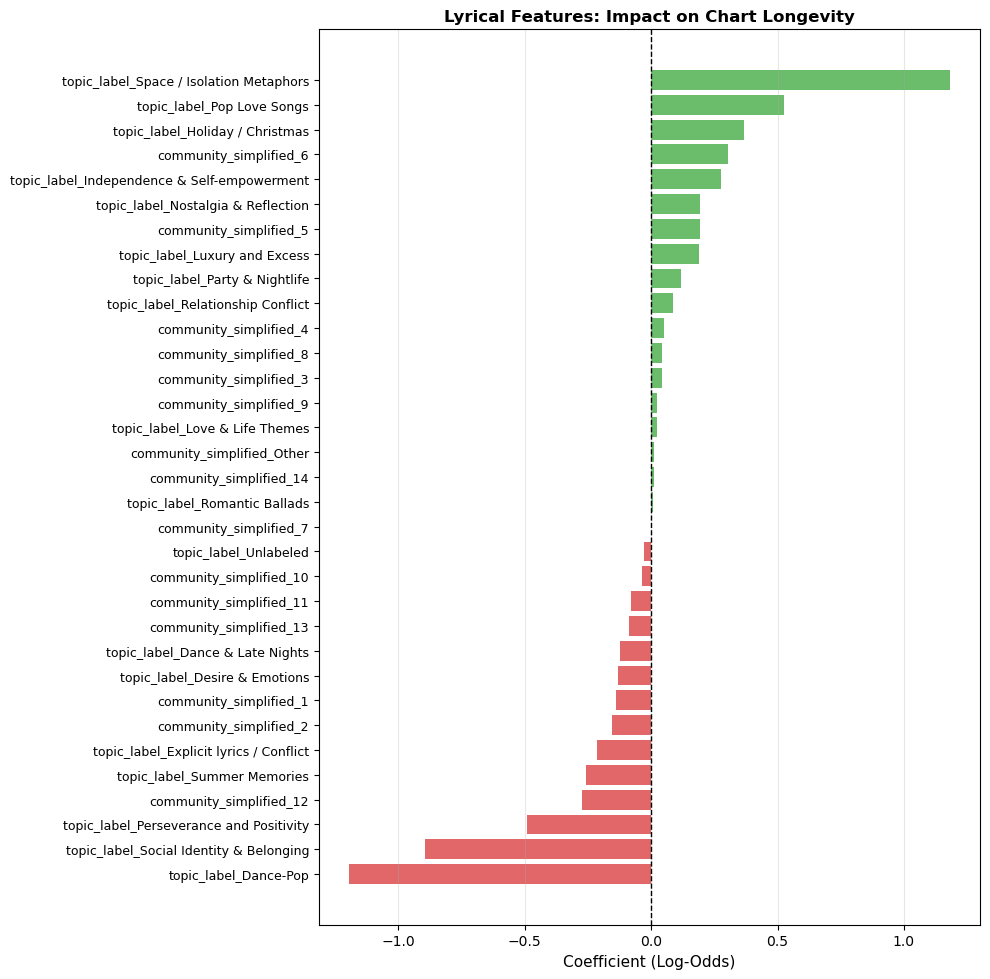

In [25]:
print("="*70)
print("LYRICAL FEATURES ANALYSIS (Research Question 2)")
print("="*70)

# Extract lyrical-related features
lyrical_keywords = ['lyrics', 'topic', 'community', 'theme']
lyrical_features = coef_df[coef_df['Feature'].str.contains('|'.join(lyrical_keywords), case=False, na=False)]

if len(lyrical_features) > 0:
    print(f"\nFound {len(lyrical_features)} lyrical features in the model:")
    print(lyrical_features.to_string(index=False))
    
    print("\n" + "-"*70)
    print("INTERPRETATION GUIDE:")
    print("-"*70)
    print("• Positive coefficients → Associated with SUSTAINED chart success")
    print("• Negative coefficients → Associated with BRIEF chart success")
    print("• Odds Ratio > 1 → Increases odds of sustained success")
    print("• Odds Ratio < 1 → Decreases odds of sustained success")
    print("\nExample: If Odds Ratio = 2.5, that feature increases the odds")
    print("         of sustained success by 150% (2.5x more likely)")
    
    # Visualize lyrical features
    if len(lyrical_features) >= 3:
        plt.figure(figsize=(10, max(6, len(lyrical_features)*0.3)))
        lyrical_sorted = lyrical_features.sort_values('Coefficient')
        colors = ['#d62728' if x < 0 else '#2ca02c' for x in lyrical_sorted['Coefficient']]
        
        plt.barh(range(len(lyrical_sorted)), lyrical_sorted['Coefficient'], color=colors, alpha=0.7)
        plt.yticks(range(len(lyrical_sorted)), lyrical_sorted['Feature'], fontsize=9)
        plt.xlabel('Coefficient (Log-Odds)', fontsize=11)
        plt.title('Lyrical Features: Impact on Chart Longevity', fontsize=12, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("\n⚠ No lyrical features found in top coefficients.")
    print("This suggests audio features dominate the prediction,")
    print("consistent with your Random Forest findings.")

In [27]:
print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

print(f"\n📊 Model Performance:")
print(f"   • Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   • Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"   • Best Parameters: {grid_search.best_params_}")

print(f"\n💾 Files Saved:")
print(f"   • Coefficient table: /Users/shannon/COMM 557/COMM 557 - Final Project/data/logistic_coefficients.csv")

print(f"\n🔍 Key Findings:")
print(f"   • Total features used: {len(feature_names)}")
print(f"   • Lyrical features found: {len(lyrical_features)}")
print(f"   • Sample size: {len(X)} songs ({len(X_train)} train, {len(X_test)} test)")


ANALYSIS COMPLETE!

📊 Model Performance:
   • Test Accuracy: 0.5280
   • Best CV F1 Score: 0.5640
   • Best Parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}

💾 Files Saved:
   • Coefficient table: /Users/shannon/COMM 557/COMM 557 - Final Project/data/logistic_coefficients.csv

🔍 Key Findings:
   • Total features used: 64
   • Lyrical features found: 33
   • Sample size: 3749 songs (2999 train, 750 test)
